In [61]:
import numpy as np
import pandas as pd
import ROOT
import seaborn as sns
from neuland_add_random_hitpar import NeulandRandHitParAdder as ParAdder
from neuland_read_hit_par import HitParReader as ParReader
from scipy import stats

In [79]:
canvas = ROOT.TCanvas("canvas", "canvas", 1200, 500)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


In [2]:
input_par_file = "/lustre/r3b/ywang/test/neuland_test/millepede/sim40M.par.root"
output_par_file = "/lustre/r3b/ywang/test/neuland_test/millepede/sim_added.par.root"

In [48]:
NUMBER_OF_BARS = 1300

par_adder = ParAdder(NUMBER_OF_BARS)
period = 150

par_adder.effective_speed.set_cos(offset=15, amp=5, period=period, err=0.1)
par_adder.t_sync.set_cos(offset=200, amp=50, period=period, err=1)
par_adder.t_diff.set_cos(offset=50, amp=25, period=period, err=0.5)
par_adder.light_attenuation_length.set_cos(offset=150, amp=10, period=period, err=1)
par_adder.energy_gain.set_cos(offset=15.0, amp=5.0, period=period, err=0.5)
par_adder.pedestal.set_cos(offset=25.0, amp=5.0, period=period, err=0.5)
par_adder.pmt_thresh.set_cos(offset=0.75, amp=0.25, period=period, err=0.5)
par_adder.saturation_coefficient.set_cos(offset=0.5, amp=0.4, period=period, err=0.5)

par_adder.insert_parameters(input_par_file, output_par_file)

Error in <TClass::New>: cannot create object of class R3B::Neuland::TrackGenerator
Error in <TBufferFile::ReadObject>: could not create object of class R3B::Neuland::TrackGenerator
Error in <TBufferFile::CheckByteCount>: object of class TObjArray read too few bytes: 66 instead of 96
Info in <TGeoManager::CloseGeometry>: Geometry loaded from file...
Info in <TGeoManager::SetTopVolume>: Top volume is cave. Master volume is cave
Info in <TGeoNavigator::BuildCache>: --- Maximum geometry depth set to 100
Info in <TGeoManager::Voxelize>: Voxelizing...
Info in <TGeoManager::CountLevels>: max level = 3, max placements = 1300
Info in <TGeoManager::CloseGeometry>: 5202 nodes/ 6 volume UID's in FAIR geometry
Info in <TGeoManager::CloseGeometry>: ----------------modeler ready----------------


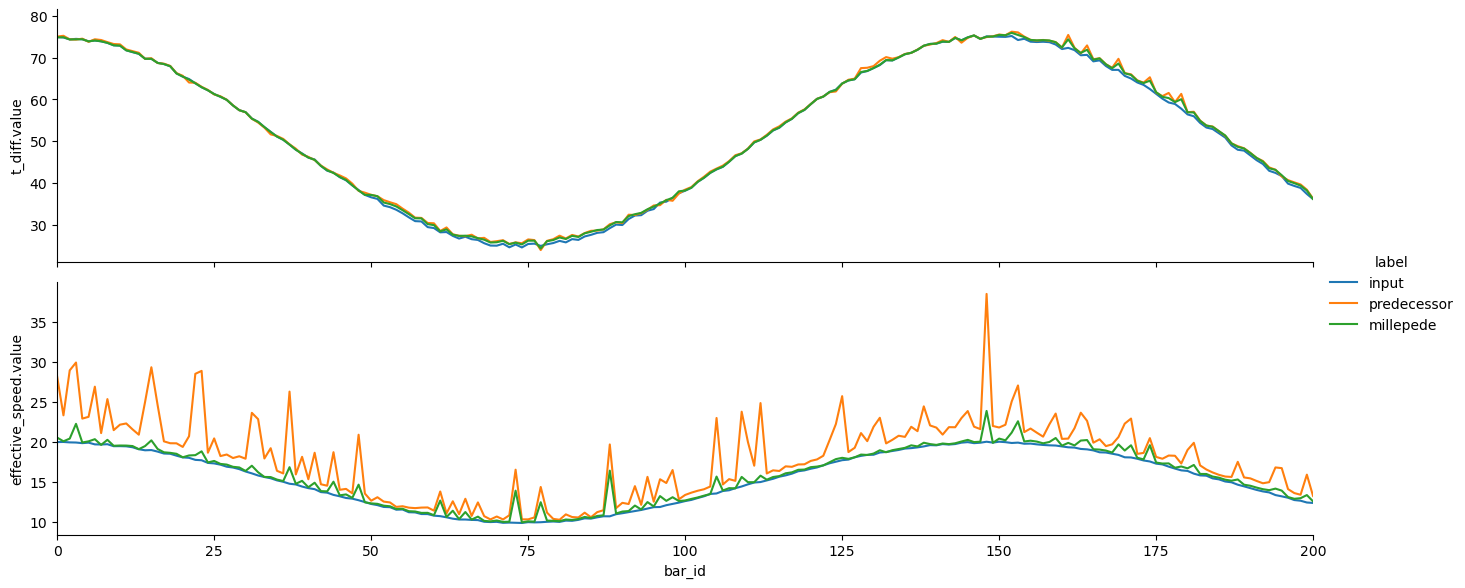

In [140]:
g = sns.PairGrid(
    data=par_df,
    x_vars=["bar_id"],
    y_vars=["t_diff.value", "effective_speed.value"],
    hue="label",
    height=3,
    aspect=4.5,
)
g.map_offdiag(sns.lineplot)
g.add_legend()
g.set(xlim=(0, 200))